In [2]:
#Importing all Libraries as requirement

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import re 
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
#NLP

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from bs4 import BeautifulSoup
from gensim.models import Word2Vec
import scipy.sparse as sp
from gensim.models import FastText
import re

In [4]:
#Model 

from sklearn.model_selection import train_test_split
from sklearn import metrics 
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
from sklearn.model_selection import StratifiedKFold , RandomizedSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression

In [5]:
df = pd.read_csv('drugsComtrain.csv', sep='\t')
print(f"Full dataset: {df.shape}")

Full dataset: (161297, 7)


In [6]:
print(df.condition.unique().shape)
print(df.isnull().sum())



(885,)
Unnamed: 0       0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64


In [7]:
condition_counts = df['condition'].value_counts().head(20)
print(condition_counts)

Birth Control                28788
Depression                    9069
Pain                          6145
Anxiety                       5904
Acne                          5588
Bipolar Disorde               4224
Insomnia                      3673
Weight Loss                   3609
Obesity                       3568
ADHD                          3383
Diabetes, Type 2              2554
Emergency Contraception       2463
High Blood Pressure           2321
Vaginal Yeast Infection       2274
Abnormal Uterine Bleeding     2096
Bowel Preparation             1859
ibromyalgia                   1791
Smoking Cessation             1780
Migraine                      1694
Anxiety and Stress            1663
Name: condition, dtype: int64


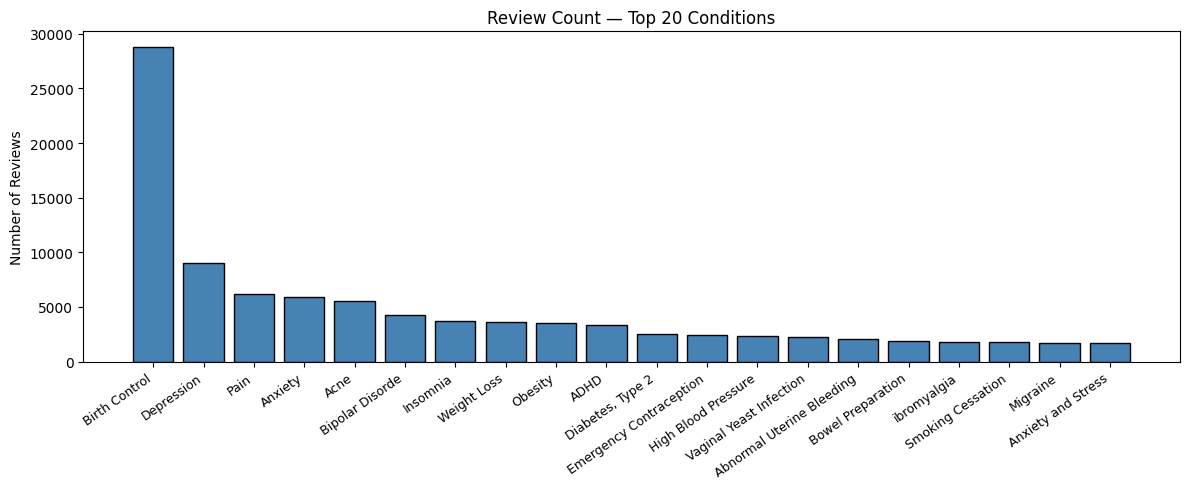

In [8]:
plt.figure(figsize=(12, 5))
plt.bar(condition_counts.index, condition_counts.values, color='steelblue', edgecolor='black')
plt.xticks(rotation=35, ha='right', fontsize=9)
plt.title('Review Count — Top 20 Conditions')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

In [9]:
# Calculating the % drop between each consecutive rank
print(f"{'Rank':<6} {'Condition':<35} {'Count':>7}  {'Drop from prev':>15}")
print("-" * 68)

for i in range(len(condition_counts)):
    count = condition_counts.iloc[i]
    if i == 0:
        drop = "—"
    else:
        prev  = condition_counts.iloc[i - 1]
        drop  = f"{(prev - count) / prev * 100:.1f}%"
    print(f"{i+1:<6} {condition_counts.index[i]:<35} {count:>7,}  {drop:>15}")

Rank   Condition                             Count   Drop from prev
--------------------------------------------------------------------
1      Birth Control                        28,788                —
2      Depression                            9,069            68.5%
3      Pain                                  6,145            32.2%
4      Anxiety                               5,904             3.9%
5      Acne                                  5,588             5.4%
6      Bipolar Disorde                       4,224            24.4%
7      Insomnia                              3,673            13.0%
8      Weight Loss                           3,609             1.7%
9      Obesity                               3,568             1.1%
10     ADHD                                  3,383             5.2%
11     Diabetes, Type 2                      2,554            24.5%
12     Emergency Contraception               2,463             3.6%
13     High Blood Pressure                   2,

In [10]:
# Checking incase 2 diseases have same meaning or any other trait is there so we found that->
# Weight Loss and Obesity good be similar so we may drop obesity
wl_reviews = ' '.join(df[df['condition'] == 'Weight Loss']['review'].astype(str).str.lower())
ob_reviews = ' '.join(df[df['condition'] == 'Obesity']['review'].astype(str).str.lower())

# Most common words (here we ignore short words and figureout if they are really one and the same thing or not)
from collections import Counter

def top_words(text, n=10):
    words = [w for w in text.split() if len(w) > 5]
    return [word for word, count in Counter(words).most_common(n)]

print("Weight Loss top words:", top_words(wl_reviews))
print("Obesity     top words:", top_words(ob_reviews))

Weight Loss top words: ['weight', 'started', 'i&#039;m', 'taking', 'pounds', 'i&#039;ve', 'effects', 'because', 'don&#039;t', 'eating']
Obesity     top words: ['weight', 'started', 'i&#039;m', 'taking', 'effects', 'i&#039;ve', 'contrave', 'pounds', 'eating', 'don&#039;t']


In [11]:
# Top 10 conditions, minus Obesity (duplicate of Weight Loss) = 9 conditions
CONDITIONS = [
    'Birth Control',    
    'Depression',       
    'Pain',             
    'Anxiety',          
    'Acne',             
    'Bipolar Disorde',  
    'Insomnia',        
    'Weight Loss',      
    'ADHD',             
]

df_filtered = df[df['condition'].isin(CONDITIONS)].copy()

print(f"Total rows selected : {len(df_filtered):,}")
print(f"% of full dataset   : {len(df_filtered) / len(df) * 100:.1f}%")
print(f"Imbalance ratio     : {df_filtered['condition'].value_counts().iloc[0] / df_filtered['condition'].value_counts().iloc[-1]:.1f}x")

Total rows selected : 70,383
% of full dataset   : 43.6%
Imbalance ratio     : 8.5x


In [12]:
# 8.5x imbalance ratio
# This means Birth Control (28,788) has 8.5x more samples than ADHD (3,383)

In [13]:
df_filtered.isnull().sum()

Unnamed: 0     0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
dtype: int64

In [14]:
df_filtered['condition'].value_counts()

Birth Control      28788
Depression          9069
Pain                6145
Anxiety             5904
Acne                5588
Bipolar Disorde     4224
Insomnia            3673
Weight Loss         3609
ADHD                3383
Name: condition, dtype: int64

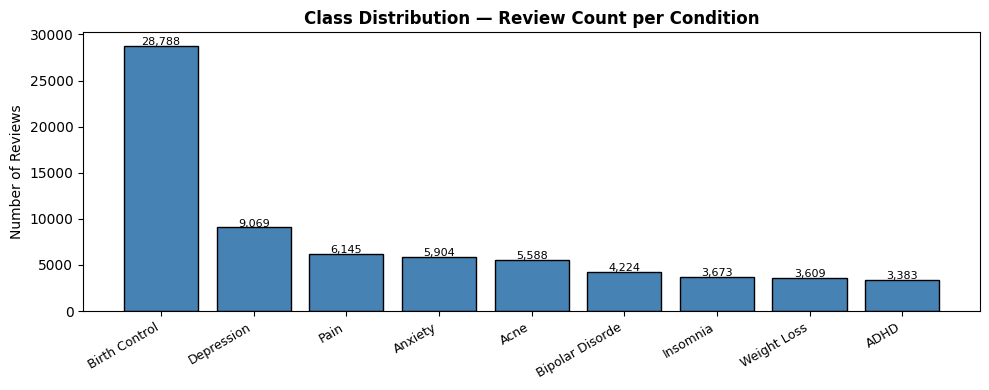

In [15]:
plt.figure(figsize=(10, 4))
counts = df_filtered['condition'].value_counts()
bars = plt.bar(counts.index, counts.values, color='steelblue', edgecolor='black')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.title('Class Distribution — Review Count per Condition', fontweight='bold')
plt.ylabel('Number of Reviews')

# Annotate each bar with count
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [16]:
# Birth Control dominates at 28k vs ADHD at 3.3k
# Confirms 8.5x imbalance —>>> use class_weight='balanced_subsample' in Random Forest

<Figure size 1000x500 with 0 Axes>

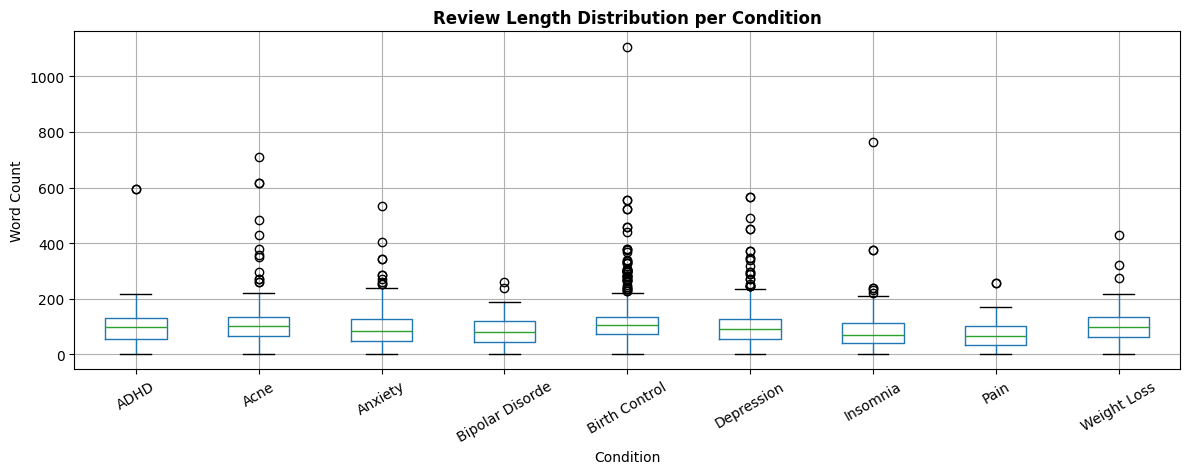

Median review length per condition:
condition
Birth Control      105.0
Acne               103.0
ADHD                99.0
Weight Loss         97.0
Depression          92.0
Anxiety             85.0
Bipolar Disorde     81.0
Insomnia            69.0
Pain                64.0


In [17]:
df_filtered['review_length'] = df_filtered['review'].str.split().str.len()

plt.figure(figsize=(10, 5))
df_filtered.boxplot(column='review_length', by='condition',
                    figsize=(12, 5), rot=30)
plt.suptitle('')
plt.title('Review Length Distribution per Condition', fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Word Count')
plt.tight_layout()
plt.show()

# Print median length per condition
print("Median review length per condition:")
print(df_filtered.groupby('condition')['review_length']
      .median().sort_values(ascending=False).to_string())

In [18]:
#What this tells you:
#If one condition has a median of 20 words vs another at 80 words.
#TF-IDF vectors will be very different in density — useful to know before you interpret results.


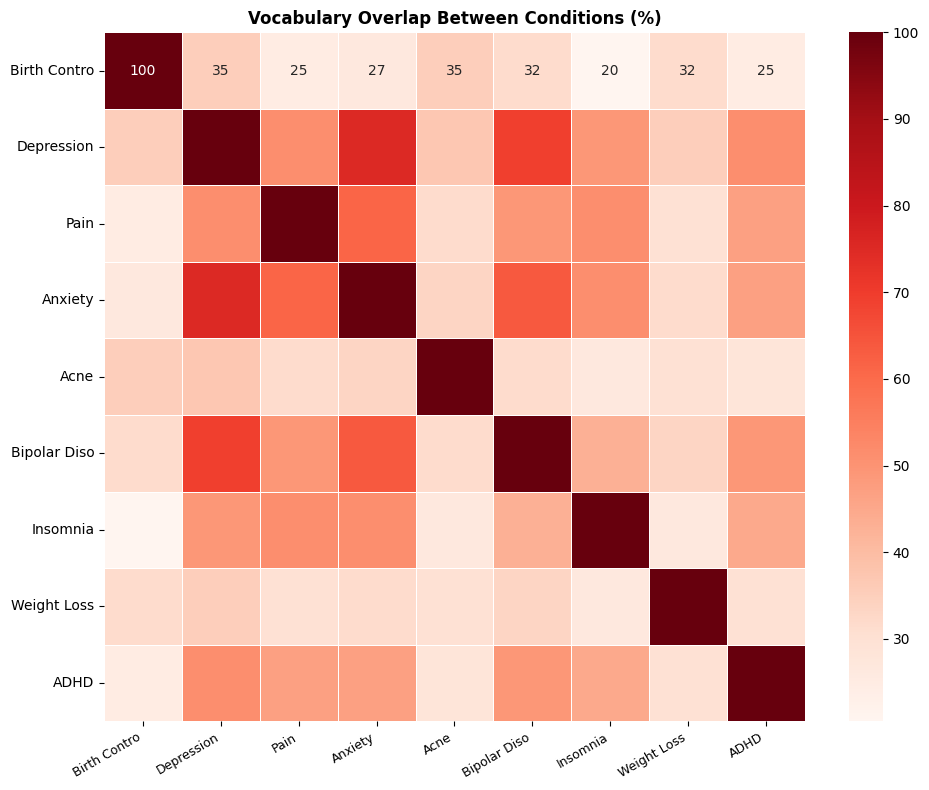

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

# Geting top 50 words per condition 
def get_top_words(condition, n=50):
    text = df_filtered[df_filtered['condition'] == condition]['review']
    cv = CountVectorizer(stop_words='english', max_features=n)
    cv.fit_transform(text)
    return set(cv.get_feature_names_out())

# Building the overlap matrix
overlap_matrix = pd.DataFrame(index=CONDITIONS, columns=CONDITIONS, dtype=float)

for c1 in CONDITIONS:
    for c2 in CONDITIONS:
        words1 = get_top_words(c1)
        words2 = get_top_words(c2)
        overlap = len(words1 & words2) / len(words1 | words2) * 100
        overlap_matrix.loc[c1, c2] = round(overlap, 1)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(overlap_matrix.astype(float), annot=True, fmt='.0f',
            cmap='Reds', linewidths=0.5,
            xticklabels=[c[:12] for c in CONDITIONS],
            yticklabels=[c[:12] for c in CONDITIONS])
plt.title('Vocabulary Overlap Between Conditions (%)', fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

In [20]:
#Vocabulary Overlap Between Conditions (the most important one)
#What this tells you directly: Any pair with >40% overlap will be hard to classify. 
#Those are the conditions where your model will make most mistakes.
#you'll see this confirmed later in the confusion matrix. 
#If Depression/Anxiety overlap heavily, you already know to expect misclassifications there before you even train.

<Figure size 1200x500 with 0 Axes>

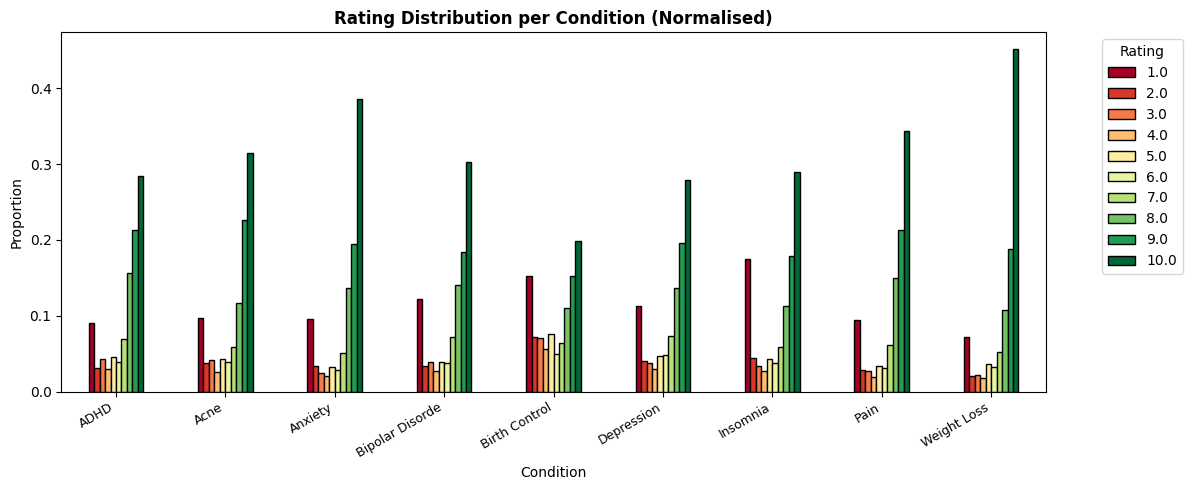

Mean rating per condition:
condition
Weight Loss        8.05
Anxiety            7.69
Pain               7.63
Acne               7.37
ADHD               7.35
Bipolar Disorde    7.15
Depression         7.10
Insomnia           6.72
Birth Control      6.09


In [21]:
plt.figure(figsize=(12, 5))
df_filtered.groupby('condition')['rating'].value_counts(normalize=True).unstack().plot(
    kind='bar', figsize=(12, 5), colormap='RdYlGn', edgecolor='black'
)
plt.title('Rating Distribution per Condition (Normalised)', fontweight='bold')
plt.xlabel('Condition')
plt.ylabel('Proportion')
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.legend(title='Rating', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Print mean rating per condition
print("Mean rating per condition:")
print(df_filtered.groupby('condition')['rating']
      .mean().sort_values(ascending=False).round(2).to_string())

In [22]:
#Rating Distribution per Condition
#What this tells you: If Acne has mostly high ratings and Depression has mostly low ratings, rating carries predictive signal.
#You can add it as a feature alongside TF-IDF.

In [23]:
stop_words = set(stopwords.words("english"))

# Keep medically important words

stop_words -= {"not", "no", "never", "without", "nor"}

In [24]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return wordnet.ADJ
    elif treebank_tag.startswith('V'): return wordnet.VERB
    elif treebank_tag.startswith('R'): return wordnet.ADV
    else: return wordnet.NOUN

In [25]:
#NLTK's pos_tag() uses Penn Treebank POS tags.

#For verbs, the tags are:

#Tag	Meaning
#VB	Verb (base form)
#VBD	Verb, past tense
#VBG	Verb, gerund/present participle
#VBN	Verb, past participle
#VBP	Verb, non-3rd person singular present
#VBZ	Verb, 3rd person singular present

#Nouns (N)

#Tag	 Meaning	             Example
#NN	    Singular noun	            dog,student
#NNS	Plural noun	            dogs, students
#NNP	Proper noun (singular)	John, India
#NNPS	Proper noun (plural)	Americans, Indians

#Adjectives (J)

#Tag	     Meaning	             Example
#JJ	         Adjective	        good, beautiful
#JJR	Comparative adjective	better, taller
#JJS	Superlative adjective	best, tallest

#Adverbs (R)

#Tag	  Meaning	            Example
#RB	      Adverb	          quickly, very
#RBR	Comparative adverb	  faster, harder
#RBS	Superlative adverb	  fastest, hardest



In [26]:
def review_to_words(raw_review):
    # Step 1: Strip HTML tags
    text = BeautifulSoup(str(raw_review), 'html.parser').get_text()
    # Step 2: Lowercase
    text = text.lower()
    # Step 3: Keep letters only
    text = re.sub('[^a-zA-Z]', ' ', text)
    # Step 4: Tokenize
    tokens = word_tokenize(text)
    # Step 5: Remove stopwords, keep tokens longer than 2 chars
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    # Step 6: POS-aware lemmatization
    pos_tags = pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(word, get_wordnet_pos(tag))
                  for word, tag in pos_tags]
    return ' '.join(lemmatized)

In [27]:
#Sanity Check
import re
test = "I started taking this medication for anxiety every day for two months. Not working."
print("Input  :", test)
print("Output :", review_to_words(test))

Input  : I started taking this medication for anxiety every day for two months. Not working.
Output : start take medication anxiety every day two month not work


In [28]:
df_filtered = df_filtered[df_filtered['review'].str.split().str.len() >= 10].copy()

In [29]:
X = df_filtered[['condition', 'review']].copy()

print("Cleaning reviews — takes ~2-3 minutes...")
X['review_clean'] = X['review'].apply(review_to_words)
print(f"✅ Done. Sample:\n{X['review_clean'].iloc[0][:300]}")

X_features = X['review_clean']
y = X['condition']

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, stratify=y, test_size=0.2, random_state=42
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

Cleaning reviews — takes ~2-3 minutes...
✅ Done. Sample:
son halfway fourth week intuniv become concerned begin last week start take high dose two day could hardly get bed cranky sleep nearly hour drive home school vacation unusual call doctor monday morning say stick day see school get morning last two day problem free much agreeable ever less emotional 

Train: 55135 | Test: 13784


In [30]:
le = LabelEncoder()
y_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print(f"Classes: {list(le.classes_)}")

Classes: ['ADHD', 'Acne', 'Anxiety', 'Bipolar Disorde', 'Birth Control', 'Depression', 'Insomnia', 'Pain', 'Weight Loss']


In [31]:
# Label encoding — XGBoost and LightGBM need numbers not strings


In [32]:
print(overlap_matrix)

                 Birth Control  Depression   Pain  Anxiety   Acne  \
Birth Control            100.0        35.1   25.0     26.6   35.1   
Depression                35.1       100.0   51.5     75.4   37.0   
Pain                      25.0        51.5  100.0     61.3   31.6   
Anxiety                   26.6        75.4   61.3    100.0   33.3   
Acne                      35.1        37.0   31.6     33.3  100.0   
Bipolar Disorde           31.6        69.5   49.3     63.9   31.6   
Insomnia                  20.5        49.3   51.5     51.5   26.6   
Weight Loss               31.6        35.1   29.9     31.6   29.9   
ADHD                      25.0        51.5   47.1     47.1   28.2   

                 Bipolar Disorde  Insomnia  Weight Loss   ADHD  
Birth Control               31.6      20.5         31.6   25.0  
Depression                  69.5      49.3         35.1   51.5  
Pain                        49.3      51.5         29.9   47.1  
Anxiety                     63.9      51.5       

In [33]:
# Tokenize cleaned reviews
tokens = [text.split() for text in X_train]
test_tokens  = [text.split() for text in X_test]

In [34]:
w2v_model = Word2Vec(
    sentences=tokens,
    vector_size=200,    
    window=5,           
    min_count=2,        # ignore words appearing < 2 times
    sg=0,               
    workers=4,
    epochs=15,
    seed=42
)

print(f"W2V vocabulary size: {len(w2v_model.wv)}")


W2V vocabulary size: 14837


In [35]:
# Sanity check — are semantically similar words clustering correctly?
# This directly validates W2V is learning condition-relevant semantics
print("\nSimilar to 'depression':", 
      [w for w,_ in w2v_model.wv.most_similar('depression', topn=5)])
print("Similar to 'anxiety'   :", 
      [w for w,_ in w2v_model.wv.most_similar('anxiety', topn=5)])
print("Similar to 'pain'      :", 
      [w for w,_ in w2v_model.wv.most_similar('pain', topn=5)])


Similar to 'depression': ['depressive', 'ocd', 'mdd', 'agoraphobia', 'ptsd']
Similar to 'anxiety'   : ['panic', 'gad', 'ocd', 'mania', 'ptsd']
Similar to 'pain'      : ['vicodin', 'discomfort', 'cramping', 'ibuprofen', 'spasm']


In [36]:
#Converting documents to W2V vectors now
def doc_to_w2v(tokens, model, vector_size=200):
    # Average all known word vectors in the document
    # Unknown words (not in vocab) are skipped
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(vector_size)  # fallback for empty docs
    return np.mean(vecs, axis=0)

X_w2v = np.array([doc_to_w2v(t, w2v_model) for t in tokens])
X_test_w2v  = np.array([doc_to_w2v(t, w2v_model) for t in test_tokens])

print(f"W2V matrix shape: {X_w2v.shape}")

W2V matrix shape: (55135, 200)


In [34]:
vectorizer = CountVectorizer(stop_words=stop_words)
tfidf = TfidfVectorizer()

In [35]:
X_train_tfidf = tfidf.fit_transform(X_train)   # fit ONLY on train — no data leakage
X_test_tfidf  = tfidf.transform(X_test)         # transform test with train's vocabulary


In [105]:
# Stack TF-IDF + W2V 
X_train_stacked = sp.hstack([
    X_tfidf,                        # sparse: (n, 80000) — token importance
    sp.csr_matrix(X_w2v)            # dense→sparse: (n, 200) — semantic context
])
X_test_stacked = sp.hstack([
    X_test_tfidf,
    sp.csr_matrix(X_test_w2v)
])

print(f"TF-IDF only shape : {X_tfidf.shape}")
print(f"Stacked shape     : {X_stacked.shape}")
print(f"Extra dimensions  : {X_stacked.shape[1] - X_tfidf.shape[1]} (W2V)")

ValueError: Mismatching dimensions along axis 0: {13784, 14077}

In [36]:
# sublinear_tf: log-normalizes term freq — stops common words dominating
# ngram_range (1,3): captures "does not work", "no side effects", "worked really well"
# min_df=2: removes rare typo-tokens
# max_features=80000: large vocab = more signal

tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    max_df=0.80,
    min_df=2,
    sublinear_tf=True,
    max_features=80000,
    token_pattern=r"[a-zA-Z_][a-zA-Z_]+"  # includes not_good, not_work tokens
)

X_train_tfidf = tfidf.fit_transform(X_train)   # fit ONLY on train — no data leakage
X_test_tfidf  = tfidf.transform(X_test)         # transform test with train's vocabulary

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")
print(f"Sample features: {tfidf.get_feature_names_out()[:15].tolist()}")

TF-IDF matrix shape: (55135, 80000)
Sample features: ['ab', 'abate', 'abdomen', 'abdomen area', 'abdomen pain', 'abdominal', 'abdominal cramp', 'abdominal cramping', 'abdominal pain', 'abdominal surgery', 'abilify', 'abilify add', 'abilify almost', 'abilify along', 'abilify cause']


In [37]:
print(f"X_train_tfidf : {X_train_tfidf.shape}")
print(f"X_test_tfidf  : {X_test_tfidf.shape}")

X_train_tfidf : (55135, 80000)
X_test_tfidf  : (13784, 80000)


In [38]:
param_dist_rf = {
    'n_estimators'     : [200, 300, 500],       
    'max_depth'        : [15, 20, 30],          
    'min_samples_split': [2, 4],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2'],       
    'class_weight'     : ['balanced_subsample'],
    'criterion'        : ['gini', 'entropy'],    
    'max_samples'      : [0.7, 0.8],             
}


In [46]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_search = RandomizedSearchCV(
    RandomForestClassifier(oob_score=True, bootstrap=True, random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train_tfidf, y_train)
best_rf = rf_search.best_estimator_

print(f"\nBest Params   : {rf_search.best_params_}")
print(f"Best CV Score : {rf_search.best_score_:.4f}")
print(f"OOB Score     : {best_rf.oob_score_:.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_rf.predict(X_test_tfidf)):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Params   : {'n_estimators': 300, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_samples': 0.8, 'max_features': 'sqrt', 'max_depth': 30, 'criterion': 'entropy', 'class_weight': 'balanced_subsample'}
Best CV Score : 0.8739
OOB Score     : 0.8737
Test Accuracy : 0.8771


In [48]:
# Check average review length after cleaning
lengths = X_train.str.split().str.len()
print(f"Average tokens per review : {lengths.mean():.1f}")
print(f"Median tokens per review  : {lengths.median():.1f}")
print(f"Reviews with < 5 tokens   : {(lengths < 5).sum()}")
print(f"TF-IDF vocab size         : {X_train_tfidf.shape[1]}")

Average tokens per review : 43.2
Median tokens per review  : 44.0
Reviews with < 5 tokens   : 113
TF-IDF vocab size         : 80000


In [49]:
# Check what a cleaned review actually looks like
sample = df_filtered['review'].iloc[0]
cleaned = review_to_words(sample)

print("ORIGINAL:")
print(sample[:300])
print("\nCLEANED:")
print(cleaned[:300])
print(f"\nOriginal word count : {len(sample.split())}")
print(f"Cleaned word count  : {len(cleaned.split())}")

ORIGINAL:
"My son is halfway through his fourth week of Intuniv. We became concerned when he began this last week, when he started taking the highest dose he will be on. For two days, he could hardly get out of bed, was very cranky, and slept for nearly 8 hours on a drive home from school vacation (very unusu

CLEANED:
son halfway fourth week intuniv become concerned begin last week start take high dose two day could hardly get bed cranky sleep nearly hour drive home school vacation unusual call doctor monday morning say stick day see school get morning last two day problem free much agreeable ever less emotional 

Original word count : 141
Cleaned word count  : 65


In [50]:
feature_names = tfidf.get_feature_names_out()
print("First 20 features:")
print(feature_names[:20].tolist())
print("\nMiddle 20 features:")
print(feature_names[40000:40020].tolist())

First 20 features:
['ab', 'abate', 'abdomen', 'abdomen area', 'abdomen pain', 'abdominal', 'abdominal cramp', 'abdominal cramping', 'abdominal pain', 'abdominal surgery', 'abilify', 'abilify add', 'abilify almost', 'abilify along', 'abilify cause', 'abilify geodon', 'abilify help', 'abilify make', 'abilify month', 'abilify not']

Middle 20 features:
['major abdominal', 'major abdominal surgery', 'major acne', 'major anxiety', 'major anxiety depression', 'major back', 'major bloat', 'major break', 'major breakout', 'major change', 'major complaint', 'major constipation', 'major cramp', 'major decrease', 'major decrease sex', 'major depression', 'major depression anxiety', 'major depression panic', 'major depression since', 'major depression start']


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Test with default RF — no tuning
rf_default = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_default.fit(X_train_tfidf, y_train)
print(f"Default RF accuracy: {accuracy_score(y_test, rf_default.predict(X_test_tfidf)):.4f}")

Default RF accuracy: 0.9171


In [52]:
param_dist_rf = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [None, 40, 50],    # None back — was the best param all along
    'min_samples_split': [2, 4],
    'min_samples_leaf' : [1, 2],
    'max_features'     : ['sqrt', 'log2'],
    'class_weight'     : ['balanced_subsample', None],  # test both
    'criterion'        : ['gini', 'entropy'],
    'max_samples'      : [0.7, 0.8, None],  # None back here too
}

In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_search = RandomizedSearchCV(
    RandomForestClassifier(oob_score=True, bootstrap=True, random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_search.fit(X_train_tfidf, y_train)
best_rf = rf_search.best_estimator_

print(f"\nBest Params   : {rf_search.best_params_}")
print(f"Best CV Score : {rf_search.best_score_:.4f}")
print(f"OOB Score     : {best_rf.oob_score_:.4f}")
print(f"Test Accuracy : {accuracy_score(y_test, best_rf.predict(X_test_tfidf)):.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Params   : {'n_estimators': 500, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_samples': 0.8, 'max_features': 'sqrt', 'max_depth': None, 'criterion': 'gini', 'class_weight': 'balanced_subsample'}
Best CV Score : 0.8937
OOB Score     : 0.9033
Test Accuracy : 0.8991


In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_default = RandomForestClassifier(oob_score=True,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_default.fit(X_train_tfidf, y_train)
print(f"Default RF accuracy : {accuracy_score(y_test, rf_default.predict(X_test_tfidf)):.4f}")
print(f"OOB Score     : {rf_default.oob_score_:.4f}")

Default RF accuracy : 0.9171
OOB Score     : 0.9181


In [66]:
best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)
best_xgb.fit(X_train_tfidf, y_enc)
print(f"XGBoost Accuracy : {accuracy_score(y_test_enc, best_xgb.predict(X_test_tfidf)):.4f}")

XGBoost Accuracy : 0.9154


In [68]:
best_lgbm = LGBMClassifier(
    n_estimators=300,
    num_leaves=63,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    boosting_type='gbdt',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
best_lgbm.fit(X_train_tfidf, y_enc)
print(f"LightGBM Accuracy : {accuracy_score(y_test_enc, best_lgbm.predict(X_test_tfidf)):.4f}")

LightGBM Accuracy : 0.9366


In [71]:
best_lgbm = LGBMClassifier(
    n_estimators=400,       
    num_leaves=127,         
    learning_rate=0.08,     
    subsample=0.8,
    colsample_bytree=0.6,   
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    boosting_type='gbdt',
    random_state=42,
    verbose=-1,
    n_jobs=-1
)
best_lgbm.fit(X_train_tfidf, y_enc)
print(f"LightGBM Accuracy : {accuracy_score(y_test_enc, best_lgbm.predict(X_test_tfidf)):.4f}")

LightGBM Accuracy : 0.9365


In [79]:
# Stacking trains a meta-learner (Logistic Regression) on top of all 3 models
# It learns WHICH model to trust more for WHICH condition
# e.g. RF might be best for Acne, XGBoost best for Depression — LR figures this out

stacking = StackingClassifier(
    estimators=[
        ('rf',   best_rf),
        ('xgb',  best_xgb),
        ('lgbm', best_lgbm),
    ],
    final_estimator=LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        multi_class='multinomial'
    ),
    cv=3,                       # 3-fold CV to build meta-features — prevents leakage
    stack_method='predict_proba',
    n_jobs=-1
)
#Took more than 1.5 hrs to Fit -> Not a very good approach honestly

In [83]:
voting = VotingClassifier(
    estimators=[
        ('rf',   best_rf),
        ('xgb',  best_xgb),
        ('lgbm', best_lgbm),
    ],
    voting='soft',
    weights=[1, 1, 2]   # lgbm slightly favored — not dominant
)

In [84]:
voting.fit(X_train_tfidf, y_enc)
y_pred_voting = voting.predict(X_test_tfidf)
print(f"Voting Ensemble Accuracy: {accuracy_score(y_test_enc, y_pred_voting):.4f}")

Voting Ensemble Accuracy: 0.9366


In [85]:
#Stacking with 3 models each taking 15 mins × 3 folds = still too long.
#Why this is fast:
#VotingClassifier just averages the already-trained model probabilities — it doesn't retrain anything.
#Since best_rf, best_xgb, best_lgbm are already trained, fitting the VotingClassifier is nearly instant.
#Takes around 5 mins


In [86]:
for w in [[1,2], [1,3], [1,4], [2,3]]:
    v = VotingClassifier(
        estimators=[('rf', best_rf), ('lgbm', best_lgbm)],
        voting='soft', weights=w
    )
    v.fit(X_train_tfidf, y_enc)
    acc = accuracy_score(y_test_enc, v.predict(X_test_tfidf))
    print(f"Weights RF:{w[0]} LGBM:{w[1]} → Accuracy: {acc:.4f}")

Weights RF:1 LGBM:2 → Accuracy: 0.9367
Weights RF:1 LGBM:3 → Accuracy: 0.9366
Weights RF:1 LGBM:4 → Accuracy: 0.9367
Weights RF:2 LGBM:3 → Accuracy: 0.9367


In [88]:
from sklearn.metrics import classification_report

y_pred_labels = le.inverse_transform(y_pred_voting)

print("Classification Report — LightGBM Final Model")
print("=" * 70)
print(classification_report(y_test, y_pred_labels, digits=4))

Classification Report — LightGBM Final Model
                 precision    recall  f1-score   support

           ADHD     0.9458    0.9272    0.9364       659
           Acne     0.9663    0.9314    0.9485      1108
        Anxiety     0.8710    0.8124    0.8407      1130
Bipolar Disorde     0.9098    0.8529    0.8805       816
  Birth Control     0.9805    0.9913    0.9859      5732
     Depression     0.8265    0.8935    0.8587      1765
       Insomnia     0.8815    0.8640    0.8727       706
           Pain     0.9535    0.9453    0.9494      1151
    Weight Loss     0.9734    0.9707    0.9721       717

       accuracy                         0.9366     13784
      macro avg     0.9232    0.9099    0.9161     13784
   weighted avg     0.9371    0.9366    0.9365     13784



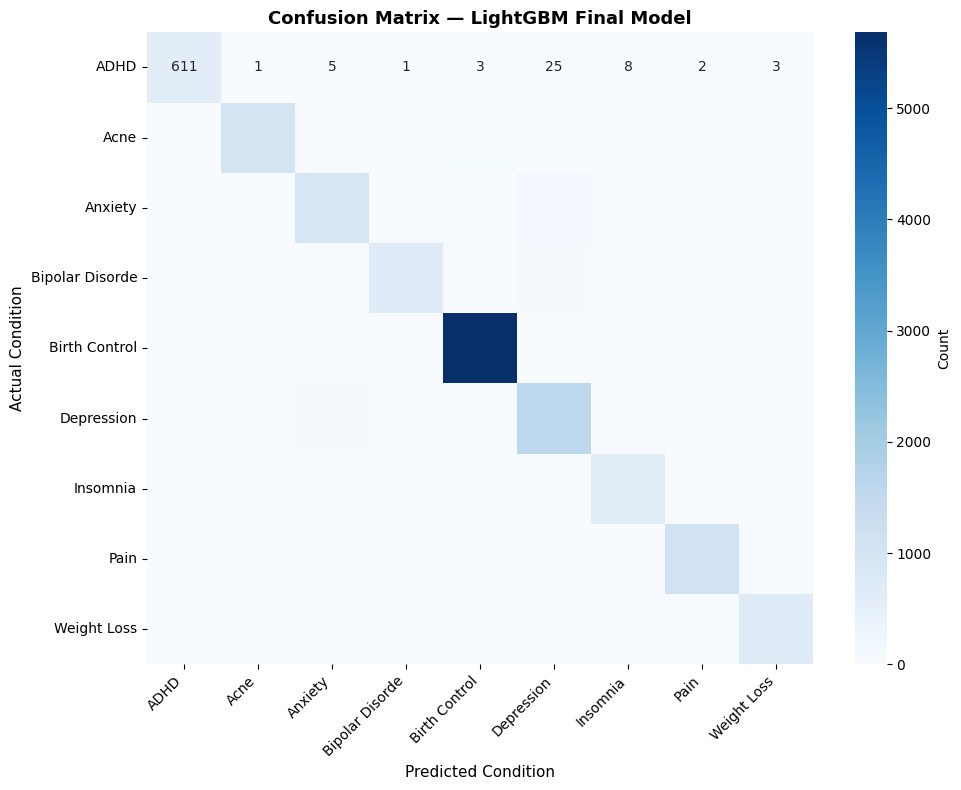

In [89]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_labels, labels=le.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix — LightGBM Final Model', fontweight='bold', fontsize=13)
plt.xlabel('Predicted Condition', fontsize=11)
plt.ylabel('Actual Condition', fontsize=11)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

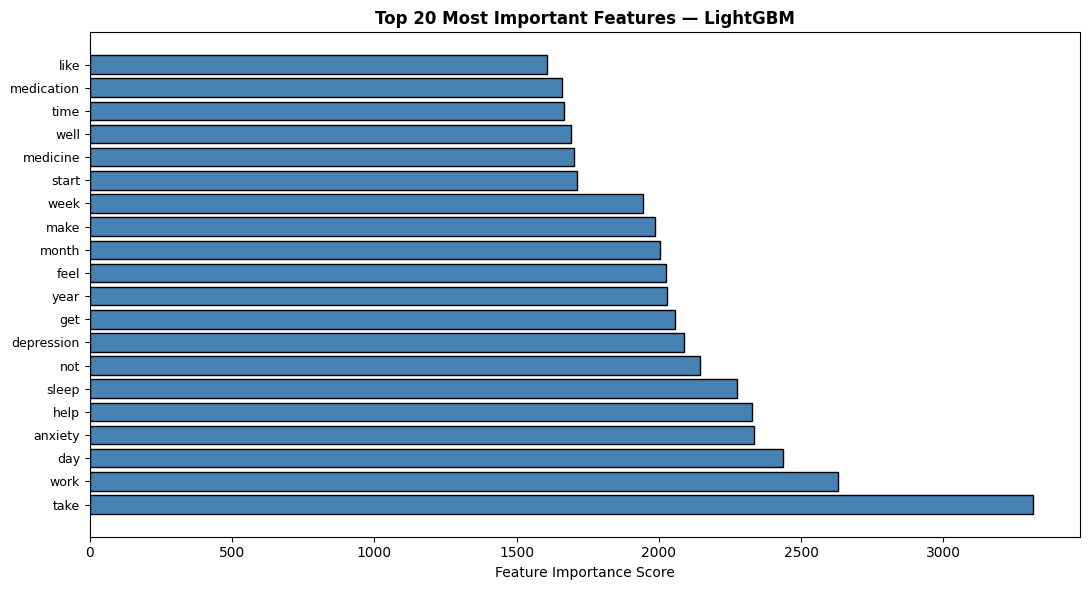


Top 20 Features by Importance:
--------------------------------------------------
 1. take                                1606.000000
 2. work                                1658.000000
 3. day                                 1668.000000
 4. anxiety                             1690.000000
 5. help                                1701.000000
 6. sleep                               1713.000000
 7. not                                 1945.000000
 8. depression                          1988.000000
 9. get                                 2004.000000
10. year                                2024.000000
11. feel                                2029.000000
12. month                               2056.000000
13. make                                2087.000000
14. week                                2146.000000
15. start                               2276.000000
16. medicine                            2328.000000
17. well                                2335.000000
18. time                         

In [90]:
import numpy as np

feature_names = tfidf.get_feature_names_out()
importances   = best_lgbm.feature_importances_

top_n = 20
top_idx = np.argsort(importances)[::-1][:top_n]

plt.figure(figsize=(11, 6))
plt.barh(range(top_n), importances[top_idx][::-1], color='steelblue', edgecolor='black')
plt.yticks(range(top_n), feature_names[top_idx][::-1], fontsize=9)
plt.title(f'Top {top_n} Most Important Features — LightGBM', fontweight='bold', fontsize=12)
plt.xlabel('Feature Importance Score', fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Print top features numerically
print(f"\nTop 20 Features by Importance:")
print("-" * 50)
for i, (idx, imp) in enumerate(zip(top_idx, importances[top_idx][::-1]), 1):
    print(f"{i:2d}. {feature_names[idx]:<35} {imp:.6f}")

In [92]:
import joblib
import scipy.sparse as sp

# Save trained models
joblib.dump(best_lgbm, 'best_lgbm_final.pkl')
joblib.dump(tfidf,     'tfidf_vectorizer.pkl')
joblib.dump(le,        'label_encoder.pkl')

# Save feature matrices (optional — for future reference)
sp.save_npz('X_train_tfidf.npz', X_train_tfidf)
sp.save_npz('X_test_tfidf.npz',  X_test_tfidf)

# Save predictions
import numpy as np
np.save('y_pred_voting.npy', y_pred_voting)
np.save('y_test_true.npy',  y_test.values)

print("✅ Model saved: best_lgbm_final.pkl")
print("✅ Vectorizer saved: tfidf_vectorizer.pkl")
print("✅ Label encoder saved: label_encoder.pkl")
print("✅ Feature matrices saved: X_train_tfidf.npz, X_test_tfidf.npz")
print("✅ Predictions saved: y_pred_final.npy, y_test_true.npy")

✅ Model saved: best_lgbm_final.pkl
✅ Vectorizer saved: tfidf_vectorizer.pkl
✅ Label encoder saved: label_encoder.pkl
✅ Feature matrices saved: X_train_tfidf.npz, X_test_tfidf.npz
✅ Predictions saved: y_pred_final.npy, y_test_true.npy


In [ ]:
#Comparing accuracy 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced_subsample',
    oob_score=True,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# TF-IDF only
rf.fit(X_train_tfidf, y_train)
acc_tfidf = accuracy_score(y_test, rf.predict(X_test_tfidf))
oob_tfidf = rf.oob_score_

# TF-IDF + W2V
rf.fit(X_train_stacked, y_train)
acc_stacked = accuracy_score(y_test, rf.predict(X_test_stacked))
oob_stacked = rf.oob_score_

print(f"TF-IDF only        — Accuracy: {acc_tfidf:.4f} | OOB: {oob_tfidf:.4f}")
print(f"TF-IDF + W2V       — Accuracy: {acc_stacked:.4f} | OOB: {oob_stacked:.4f}")
print(f"Difference         : {(acc_stacked - acc_tfidf)*100:+.2f}%")


#TF-IDF only        —> Accuracy: 0.9177 | OOB: 0.9169
#TF-IDF + W2V    —> Accuracy: 0.9069 | OOB: 0.9031
#Difference         : -1.09%


In [58]:
ft_model = FastText(
    sentences=tokens,
    vector_size=200,
    window=5,
    min_count=2,
    sg=1,          # Skip-gram — better for rare/misspelled medical words
    workers=4,
    epochs=15,
    min_n=3,       # character n-gram min length
    max_n=6,       # character n-gram max length
    seed=42
)

In [60]:
def doc_to_ft(tokens, model, vector_size=200):
    # FastText never returns OOV — infers from character n-grams
    vecs = [model.wv[w] for w in tokens]
    if len(vecs) == 0:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)

X_train_ft = np.array([doc_to_ft(t, ft_model) for t in tokens])
X_test_ft  = np.array([doc_to_ft(t, ft_model) for t in test_tokens])

print(f"FastText matrix shape: {X_train_ft.shape}")

FastText matrix shape: (56306, 200)


In [61]:
X_train_stacked_ft = sp.hstack([
    X_train_tfidf,
    sp.csr_matrix(X_train_ft)
])
X_test_stacked_ft = sp.hstack([
    X_test_tfidf,
    sp.csr_matrix(X_test_ft)
])

print(f"TF-IDF only shape       : {X_train_tfidf.shape}")
print(f"TF-IDF + FastText shape : {X_train_stacked_ft.shape}")
print(f"Extra dimensions        : {X_train_stacked_ft.shape[1] - X_train_tfidf.shape[1]} (FastText)")

TF-IDF only shape       : (56306, 25052)
TF-IDF + FastText shape : (56306, 25252)
Extra dimensions        : 200 (FastText)


In [62]:
# TF-IDF + FastText
rf.fit(X_train_stacked_ft, y_train)
acc_ft     = accuracy_score(y_test, rf.predict(X_test_stacked_ft))
oob_ft     = rf.oob_score_

print(f"TF-IDF only          — Accuracy: {acc_tfidf:.4f} | OOB: {oob_tfidf:.4f}")
print(f"TF-IDF + FastText    — Accuracy: {acc_ft:.4f}    | OOB: {oob_ft:.4f}")
print(f"Difference           : {(acc_ft - acc_tfidf)*100:+.2f}%")
print()
if acc_ft > acc_tfidf:
    print("✅ FastText helps — use X_train_stacked_ft going forward")
else:
    print("❌ FastText doesn't help — stick with X_train_tfidf")

TF-IDF only          — Accuracy: 0.9177 | OOB: 0.9169
TF-IDF + FastText    — Accuracy: 0.9072    | OOB: 0.9036
Difference           : -1.06%

❌ FastText doesn't help — stick with X_train_tfidf


In [64]:
# all three stacked
X_train_all = sp.hstack([X_train_tfidf, sp.csr_matrix(X_w2v), sp.csr_matrix(X_train_ft)])
X_test_all  = sp.hstack([X_test_tfidf,  sp.csr_matrix(X_test_w2v),  sp.csr_matrix(X_test_ft)])
print(f"All three stacked shape: {X_train_all.shape}")

All three stacked shape: (56306, 25452)


In [66]:
rf.fit(X_train_all, y_train)
print("Fit Done")
results = {}

results['TF-IDF + W2V + FastText'] = {
    'acc': accuracy_score(y_test, rf.predict(X_test_all)),
    'oob': rf.oob_score_
}

Fit Done


In [67]:
print(results)

{'TF-IDF + W2V + FastText': {'acc': 0.9094267244441288, 'oob': 0.906208929776578}}


In [68]:
# Only TFIDF is the best!